## C.1 Freeze Part C inputs

We use the curated outputs from Part B without reopening filtering decisions. The analysis is restricted to retained biological samples and retained feature sets exported at the end of Part B. We keep the 197 main retained features as the primary discovery space and the 54 high-confidence features as a conservative reference set. Redundancy annotations are also carried forward to avoid over-counting correlated LC-MS signals.

In [2]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from task1_discriminatory import (
    load_partc_ready_inputs,
    build_partc_task_table,
    compute_partc_pca,
    plot_partc_pca,
    build_all_pairwise_univariate_evidence,
    plot_univariate_screen,
    plot_top_univariate_features,
)

In [3]:
partc_inputs = load_partc_ready_inputs()
task_table = build_partc_task_table()

freeze_summary = pd.DataFrame(
    {
        "artifact": [
            "retained_biological_samples",
            "main_retained_features",
            "high_confidence_features",
            "representative_features",
        ],
        "n": [
            partc_inputs["partc_sample_metadata"]["sample"].nunique(),
            len(partc_inputs["feature_manifest_main"]),
            len(partc_inputs["feature_manifest_high"]),
            len(partc_inputs["feature_manifest_representative"]),
        ],
    }
)

display(freeze_summary)
display(task_table)

,artifact,n
0,retained_biological_samples,76
1,main_retained_features,197
2,high_confidence_features,54
3,representative_features,30


,task_name,task_type,positive_class,negative_class,task_label
0,French_vs_Dunn,pairwise,French,Dunn,Lung cancer vs healthy
1,French_vs_LMU,pairwise,French,LMU,Lung cancer vs benign disease
2,LMU_vs_Dunn,pairwise,LMU,Dunn,Benign disease vs healthy
3,three_class_overview,multiclass,NaN,NaN,Three-class overview


The Part C input is frozen from the processed Part B outputs. This keeps the discriminatory analysis reproducible and avoids mixing feature selection with downstream biomarker evaluation.

## C.2 Define discrimination tasks

We separate the discriminatory analysis into three pairwise clinical comparisons and one three-class overview. This makes the interpretation clearer: French vs Dunn measures cancer vs healthy separation, French vs LMU measures cancer specificity against benign disease, and LMU vs Dunn captures non-cancer disease effects.

## C.3 Visual discrimination check

Before statistical testing, we inspect whether the retained matrix already contains class structure. PCA is used here as a diagnostic tool rather than as final biomarker evidence. We compare the main retained matrix and the high-confidence subset to see whether the global separation is stable.

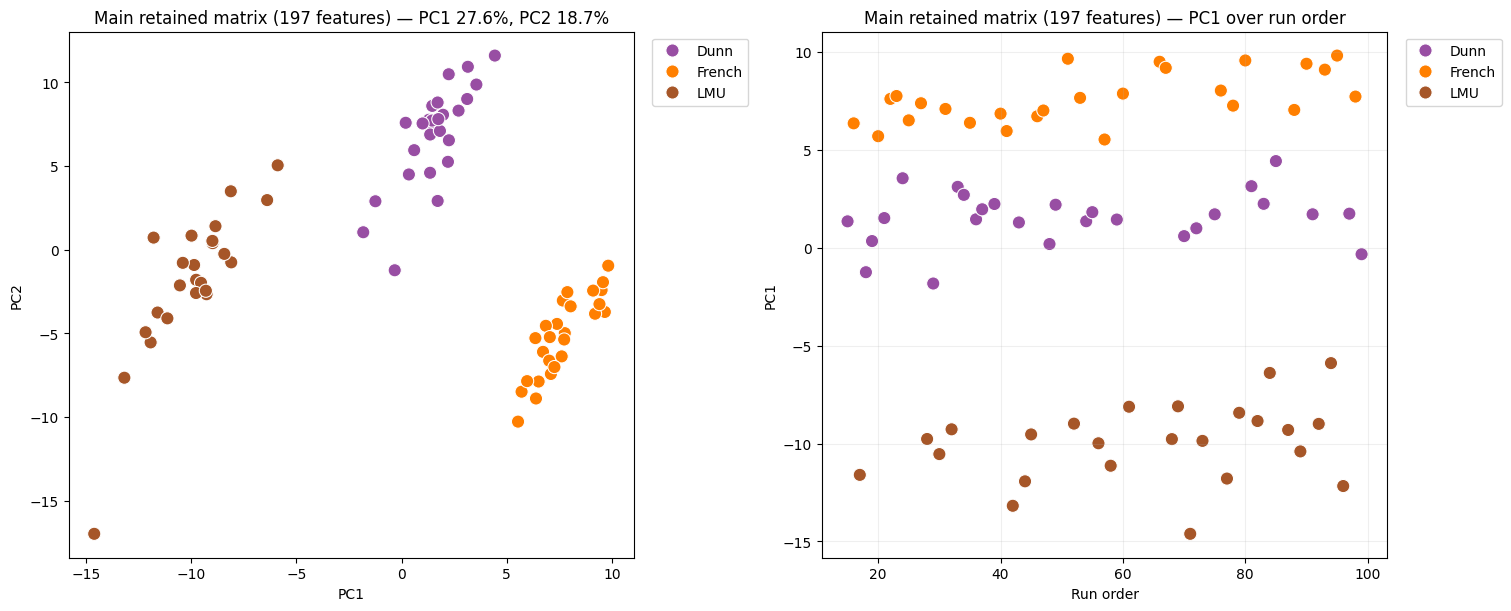

In [4]:
main_pca_scores, main_pca_evr = compute_partc_pca(
    modeling_matrix=partc_inputs["partc_matrix_main"],
    sample_metadata=partc_inputs["partc_sample_metadata"],
)

fig = plot_partc_pca(
    pca_scores=main_pca_scores,
    explained_variance_ratio=main_pca_evr,
    title_prefix="Main retained matrix (197 features)",
)
plt.show()

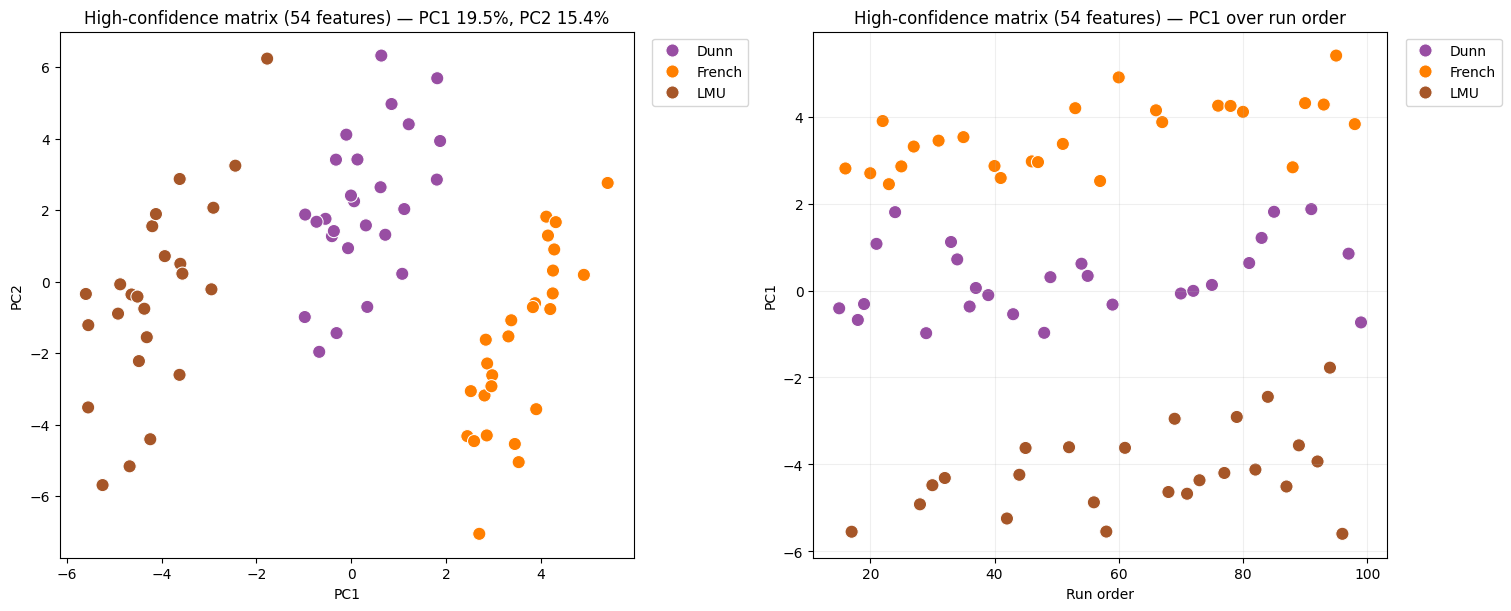

In [5]:
high_pca_scores, high_pca_evr = compute_partc_pca(
    modeling_matrix=partc_inputs["partc_matrix_high"],
    sample_metadata=partc_inputs["partc_sample_metadata"],
)

fig = plot_partc_pca(
    pca_scores=high_pca_scores,
    explained_variance_ratio=high_pca_evr,
    title_prefix="High-confidence matrix (54 features)",
)
plt.show()

### Interpretation of low-dimensional structure

Both the main retained matrix and the high-confidence subset show clear class separation, indicating that the Part B curation preserved strong discriminatory structure. The class pattern remains stable after moving to the stricter 54-feature subset, which suggests that the signal is not driven only by weak or noisy features. PC1 does not appear to be dominated by a simple run-order trend, so the main separation is unlikely to be explained only by acquisition drift.

## C.4 Univariate screening

For each pairwise task we compute feature-level statistical and discriminatory evidence. We combine effect size, FDR-controlled significance, AUC, and detection differences so that the ranking does not depend on a single metric.

In [6]:
pairwise_tables_main, pairwise_evidence_main = build_all_pairwise_univariate_evidence(
    partc_inputs=partc_inputs,
    task_table=task_table,
    feature_space="main",
)

pairwise_tables_high, pairwise_evidence_high = build_all_pairwise_univariate_evidence(
    partc_inputs=partc_inputs,
    task_table=task_table,
    feature_space="high",
)

In [7]:
summary_cols = [
    "rank_within_task",
    "feature",
    "mz",
    "rt",
    "effect_direction",
    "raw_log2_fc",
    "auc_positive_class",
    "auc_abs",
    "cliffs_delta",
    "p_value",
    "q_value",
    "positive_detection_rate_raw",
    "negative_detection_rate_raw",
    "redundancy_cluster_id",
    "redundancy_representative_flag",
]

for task_name in ["French_vs_Dunn", "French_vs_LMU", "LMU_vs_Dunn"]:
    print(f"\n===== {task_name} — main retained feature space =====")
    display(pairwise_tables_main[task_name][summary_cols].head(15))


===== French_vs_Dunn — main retained feature space =====


,rank_within_task,feature,mz,rt,effect_direction,raw_log2_fc,auc_positive_class,auc_abs,cliffs_delta,p_value,q_value,positive_detection_rate_raw,negative_detection_rate_raw,redundancy_cluster_id,redundancy_representative_flag
0,1,FT-046,1004.167127,1156.358765,French > Dunn,0.173054,1.0,1.0,1.0,6.547527e-10,6.788751e-09,1.0,1.0,RG-017,True
1,2,FT-050,1004.669624,1156.392579,French > Dunn,0.131404,1.0,1.0,1.0,6.547527e-10,6.788751e-09,1.0,1.0,RG-017,False
2,3,FT-104,1222.286477,1258.186403,French > Dunn,0.275660,1.0,1.0,1.0,6.547527e-10,6.788751e-09,1.0,1.0,RG-009,False
3,4,FT-140,1223.288380,1257.861754,French > Dunn,0.182035,1.0,1.0,1.0,6.547527e-10,6.788751e-09,1.0,1.0,RG-009,False
4,5,FT-100,1222.789011,1257.988728,French > Dunn,0.209520,1.0,1.0,1.0,6.547527e-10,6.788751e-09,1.0,1.0,RG-009,False
5,6,FT-084,1224.297876,1257.737601,French > Dunn,0.148824,1.0,1.0,1.0,6.547527e-10,6.788751e-09,1.0,1.0,RG-009,False
6,7,FT-049,1097.222577,1176.929296,French < Dunn,-0.507568,0.0,1.0,-1.0,6.547527e-10,6.788751e-09,1.0,1.0,RG-010,False
7,8,FT-218,945.149953,1013.699715,French < Dunn,-0.708614,0.0,1.0,-1.0,6.547527e-10,6.788751e-09,1.0,1.0,RG-021,False
8,9,FT-020,842.577394,963.323589,French < Dunn,-0.470257,0.0,1.0,-1.0,6.547527e-10,6.788751e-09,1.0,1.0,RG-026,False
9,10,FT-021,842.075679,963.278928,French < Dunn,-0.466763,0.0,1.0,-1.0,6.547527e-10,6.788751e-09,1.0,1.0,RG-026,True



===== French_vs_LMU — main retained feature space =====


,rank_within_task,feature,mz,rt,effect_direction,raw_log2_fc,auc_positive_class,auc_abs,cliffs_delta,p_value,q_value,positive_detection_rate_raw,negative_detection_rate_raw,redundancy_cluster_id,redundancy_representative_flag
0,1,FT-172,886.635261,674.188516,French > LMU,5.158927,1.0,1.0,1.0,1.387025e-09,8.212233e-09,1.0,0.25,RG-008,False
1,2,FT-043,1005.172042,1156.385535,French > LMU,0.792127,1.0,1.0,1.0,1.459026e-09,8.212233e-09,1.0,1.00,RG-017,False
2,3,FT-046,1004.167127,1156.358765,French > LMU,0.778632,1.0,1.0,1.0,1.459026e-09,8.212233e-09,1.0,1.00,RG-017,True
3,4,FT-050,1004.669624,1156.392579,French > LMU,0.784939,1.0,1.0,1.0,1.459026e-09,8.212233e-09,1.0,1.00,RG-017,False
4,5,FT-031,923.623393,1057.596400,French > LMU,0.353381,1.0,1.0,1.0,1.459026e-09,8.212233e-09,1.0,1.00,RG-024,True
5,6,FT-033,924.627631,1057.724634,French > LMU,0.348526,1.0,1.0,1.0,1.459026e-09,8.212233e-09,1.0,1.00,RG-024,False
6,7,FT-064,1149.750094,1245.272856,French > LMU,0.505004,1.0,1.0,1.0,1.459026e-09,8.212233e-09,1.0,1.00,RG-015,False
7,8,FT-070,1150.753810,1245.288152,French > LMU,0.482491,1.0,1.0,1.0,1.459026e-09,8.212233e-09,1.0,1.00,RG-015,False
8,9,FT-100,1222.789011,1257.988728,French > LMU,0.322387,1.0,1.0,1.0,1.459026e-09,8.212233e-09,1.0,1.00,RG-009,False
9,10,FT-232,1151.762506,1245.240779,French > LMU,0.542496,1.0,1.0,1.0,1.459026e-09,8.212233e-09,1.0,1.00,RG-015,False



===== LMU_vs_Dunn — main retained feature space =====


,rank_within_task,feature,mz,rt,effect_direction,raw_log2_fc,auc_positive_class,auc_abs,cliffs_delta,p_value,q_value,positive_detection_rate_raw,negative_detection_rate_raw,redundancy_cluster_id,redundancy_representative_flag
0,1,FT-133,1088.355496,1455.618809,LMU > Dunn,0.538662,1.0,1.0,1.0,1.459026e-09,1.197617e-08,1.0,1.0,RG-007,False
1,2,FT-068,1150.252473,1279.788424,LMU > Dunn,0.334909,1.0,1.0,1.0,1.459026e-09,1.197617e-08,1.0,1.0,RG-015,False
2,3,FT-152,1088.692773,1455.336239,LMU > Dunn,0.655284,1.0,1.0,1.0,1.459026e-09,1.197617e-08,1.0,1.0,RG-007,False
3,4,FT-127,1089.362182,1455.037944,LMU > Dunn,0.635565,1.0,1.0,1.0,1.459026e-09,1.197617e-08,1.0,1.0,RG-007,False
4,5,FT-123,1089.026571,1455.280497,LMU > Dunn,0.633242,1.0,1.0,1.0,1.459026e-09,1.197617e-08,1.0,1.0,RG-007,False
5,6,FT-043,1005.172042,1156.385535,LMU < Dunn,-0.676325,0.0,1.0,-1.0,1.459026e-09,1.197617e-08,1.0,1.0,RG-017,False
6,7,FT-046,1004.167127,1156.358765,LMU < Dunn,-0.605579,0.0,1.0,-1.0,1.459026e-09,1.197617e-08,1.0,1.0,RG-017,True
7,8,FT-050,1004.669624,1156.392579,LMU < Dunn,-0.653535,0.0,1.0,-1.0,1.459026e-09,1.197617e-08,1.0,1.0,RG-017,False
8,9,FT-218,945.149953,1013.699715,LMU < Dunn,-0.433482,0.0,1.0,-1.0,1.459026e-09,1.197617e-08,1.0,1.0,RG-021,False
9,10,FT-064,1149.750094,1245.272856,LMU < Dunn,-0.456430,0.0,1.0,-1.0,1.459026e-09,1.197617e-08,1.0,1.0,RG-015,False


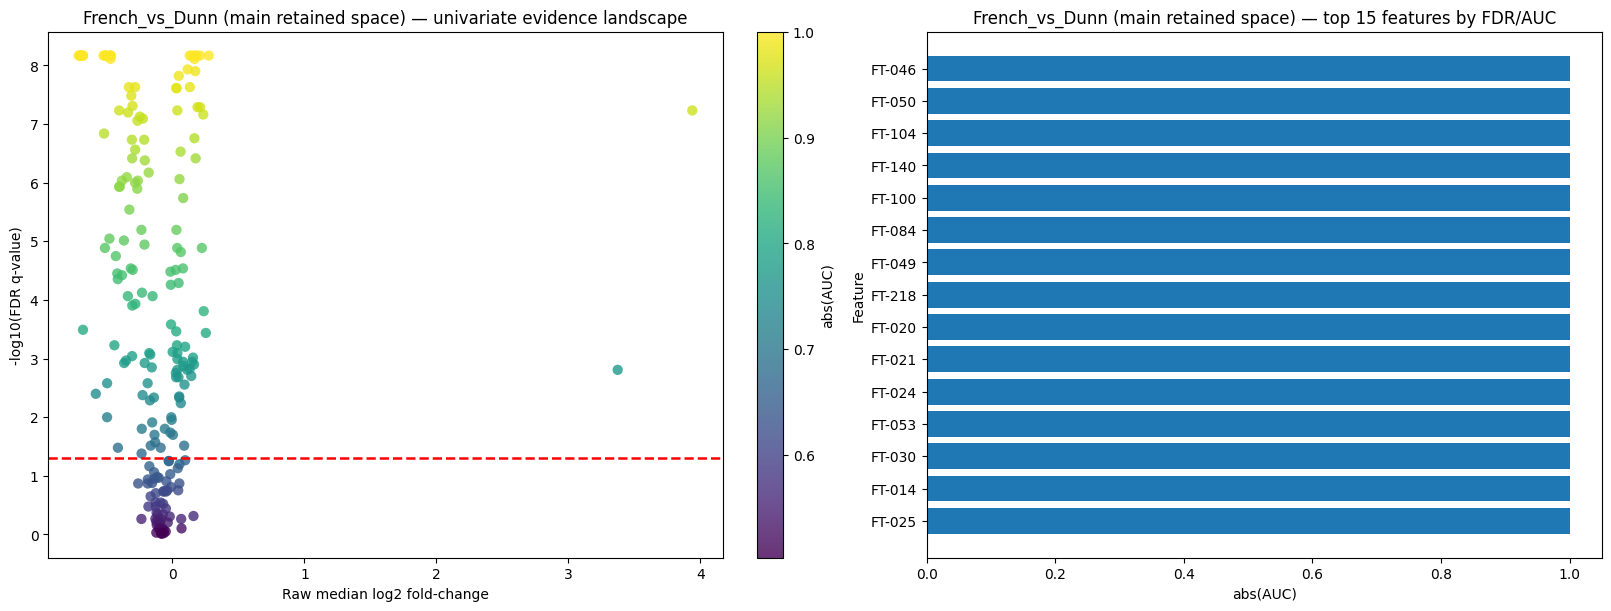

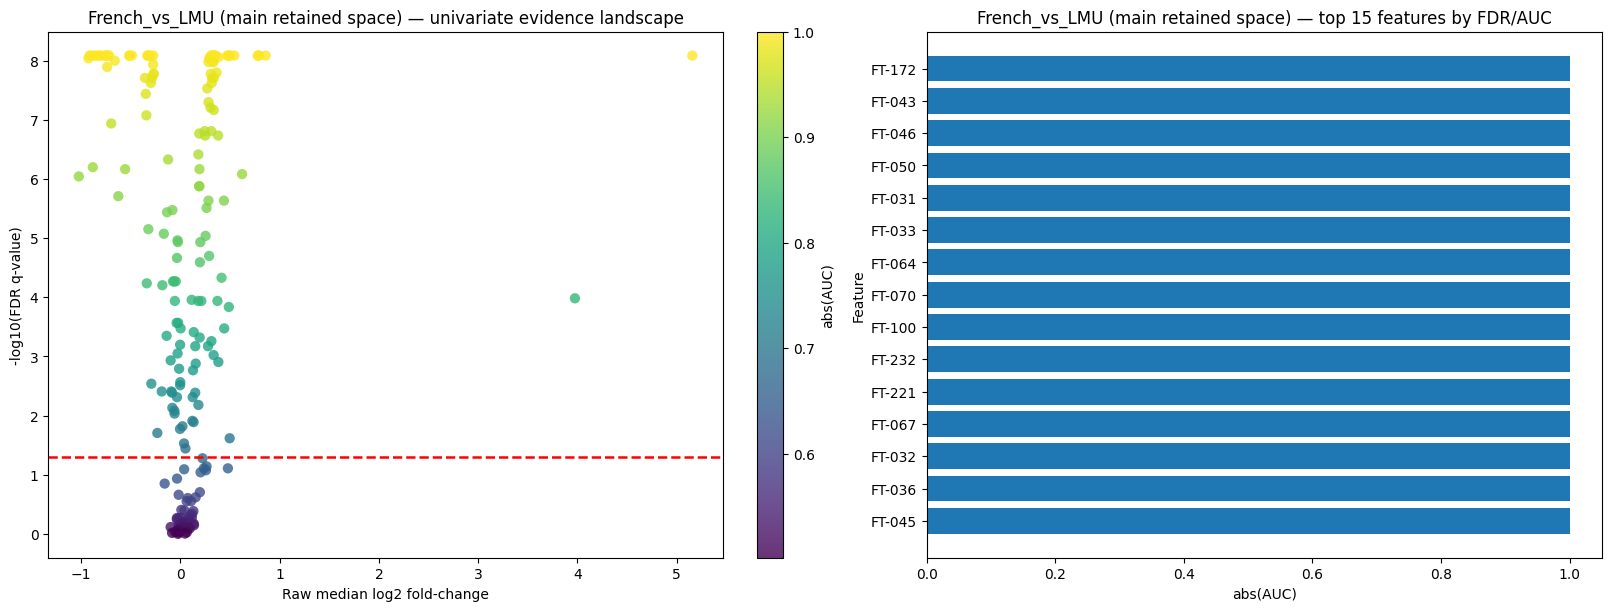

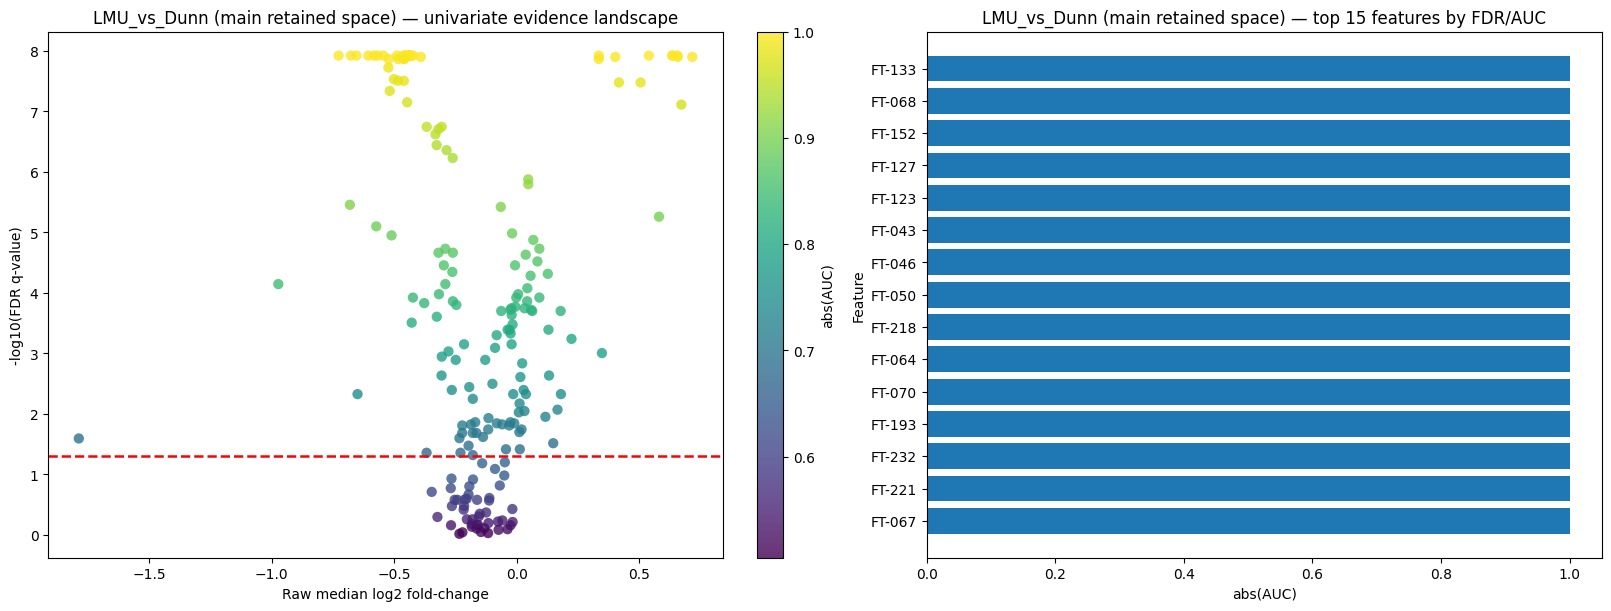

In [8]:
for task_name in ["French_vs_Dunn", "French_vs_LMU", "LMU_vs_Dunn"]:
    fig = plot_univariate_screen(
        evidence_table=pairwise_tables_main[task_name],
        title=f"{task_name} (main retained space)",
        top_n=15,
    )
    plt.show()

### Interpretation of univariate evidence

The pairwise evidence tables show that many retained features are strongly associated with class differences, with consistent effect direction, large absolute AUC, and very small FDR-adjusted q-values. French vs Dunn and French vs LMU are especially well separated, while LMU vs Dunn remains strong but slightly more heterogeneous. Because many top-ranked features belong to the same redundancy clusters, these results should be interpreted as signal families rather than as fully independent biomarkers.

c:\Users\zakar\OneDrive\Bureau\ml-internship\src\task1_discriminatory.py:562: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\zakar\OneDrive\Bureau\ml-internship\src\task1_discriminatory.py:562: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\zakar\OneDrive\Bureau\ml-internship\src\task1_discriminatory.py:562: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\zakar\OneDrive\Bureau\ml-internship\src\task1_discriminatory.py:562: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

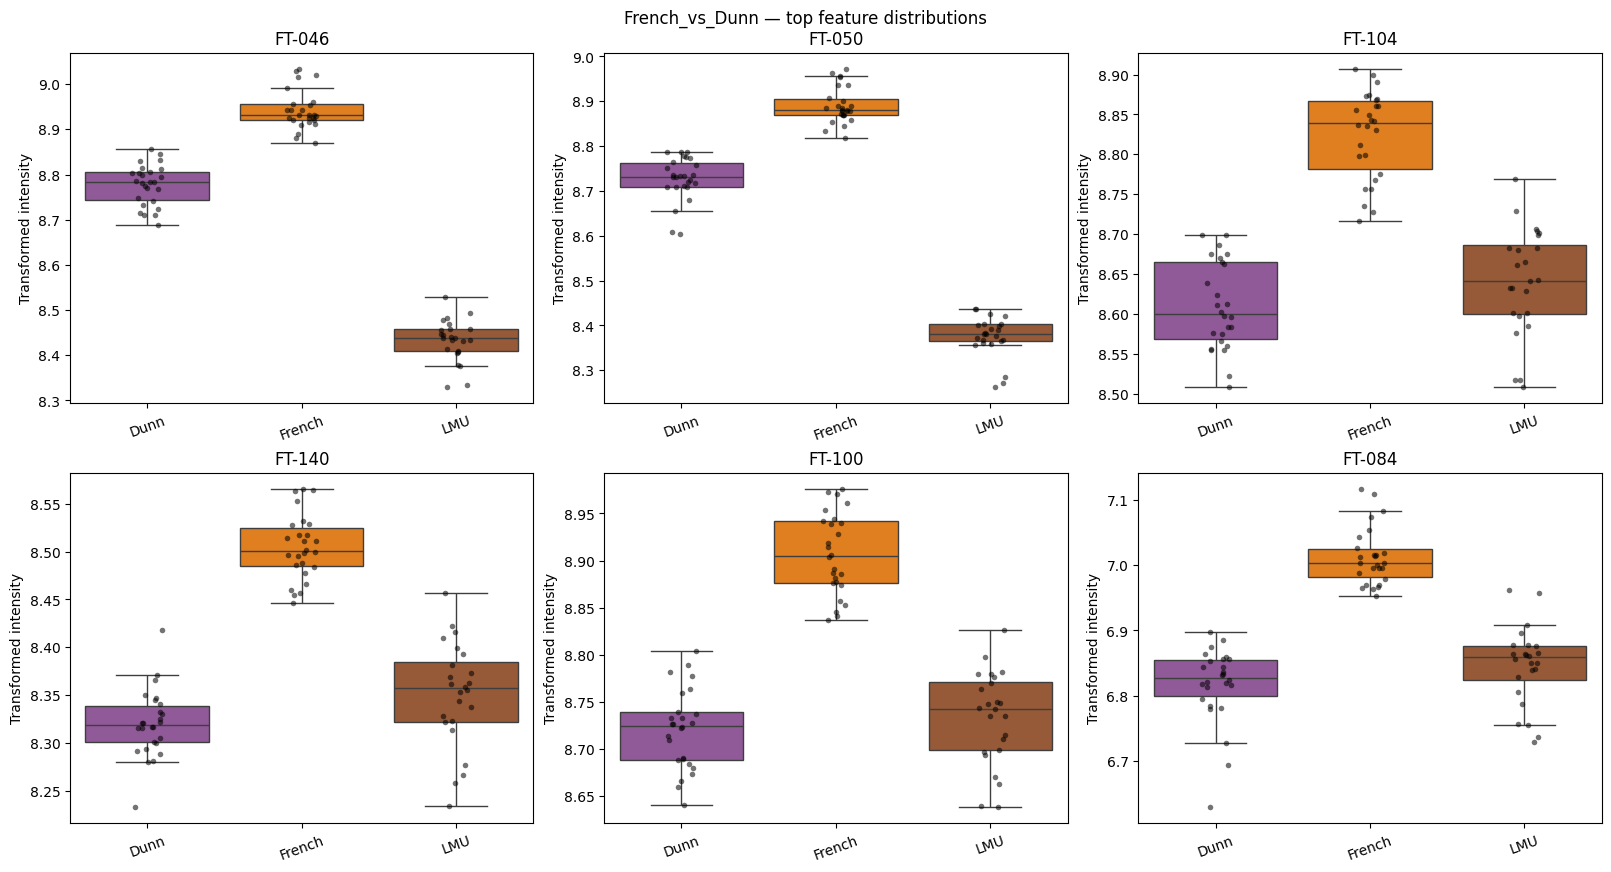

c:\Users\zakar\OneDrive\Bureau\ml-internship\src\task1_discriminatory.py:562: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\zakar\OneDrive\Bureau\ml-internship\src\task1_discriminatory.py:562: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\zakar\OneDrive\Bureau\ml-internship\src\task1_discriminatory.py:562: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\zakar\OneDrive\Bureau\ml-internship\src\task1_discriminatory.py:562: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

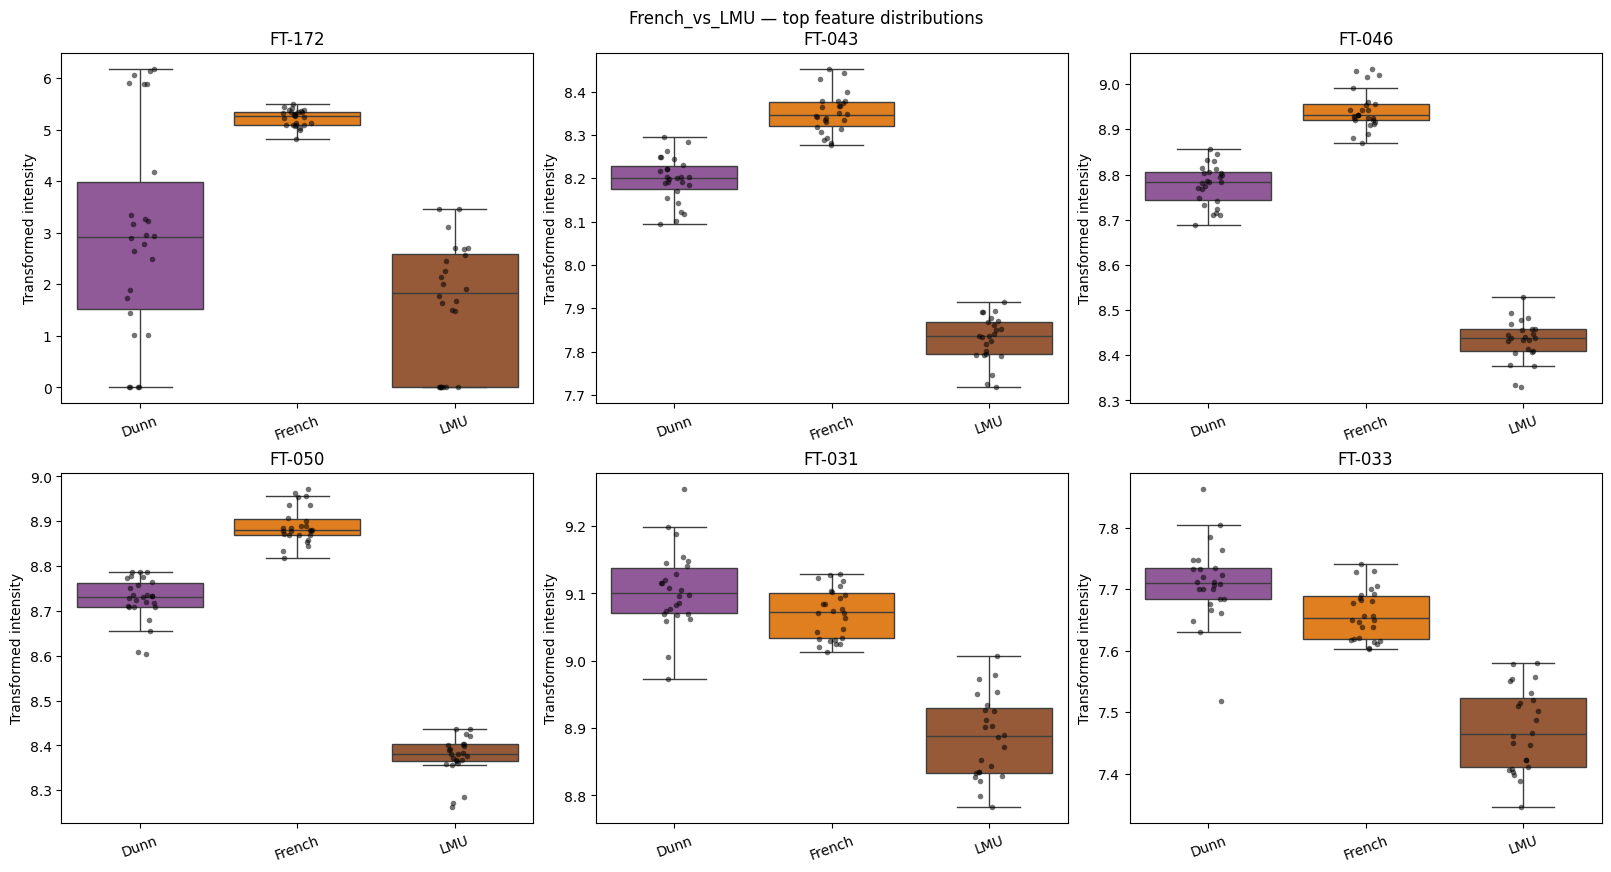

c:\Users\zakar\OneDrive\Bureau\ml-internship\src\task1_discriminatory.py:562: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\zakar\OneDrive\Bureau\ml-internship\src\task1_discriminatory.py:562: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\zakar\OneDrive\Bureau\ml-internship\src\task1_discriminatory.py:562: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\zakar\OneDrive\Bureau\ml-internship\src\task1_discriminatory.py:562: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

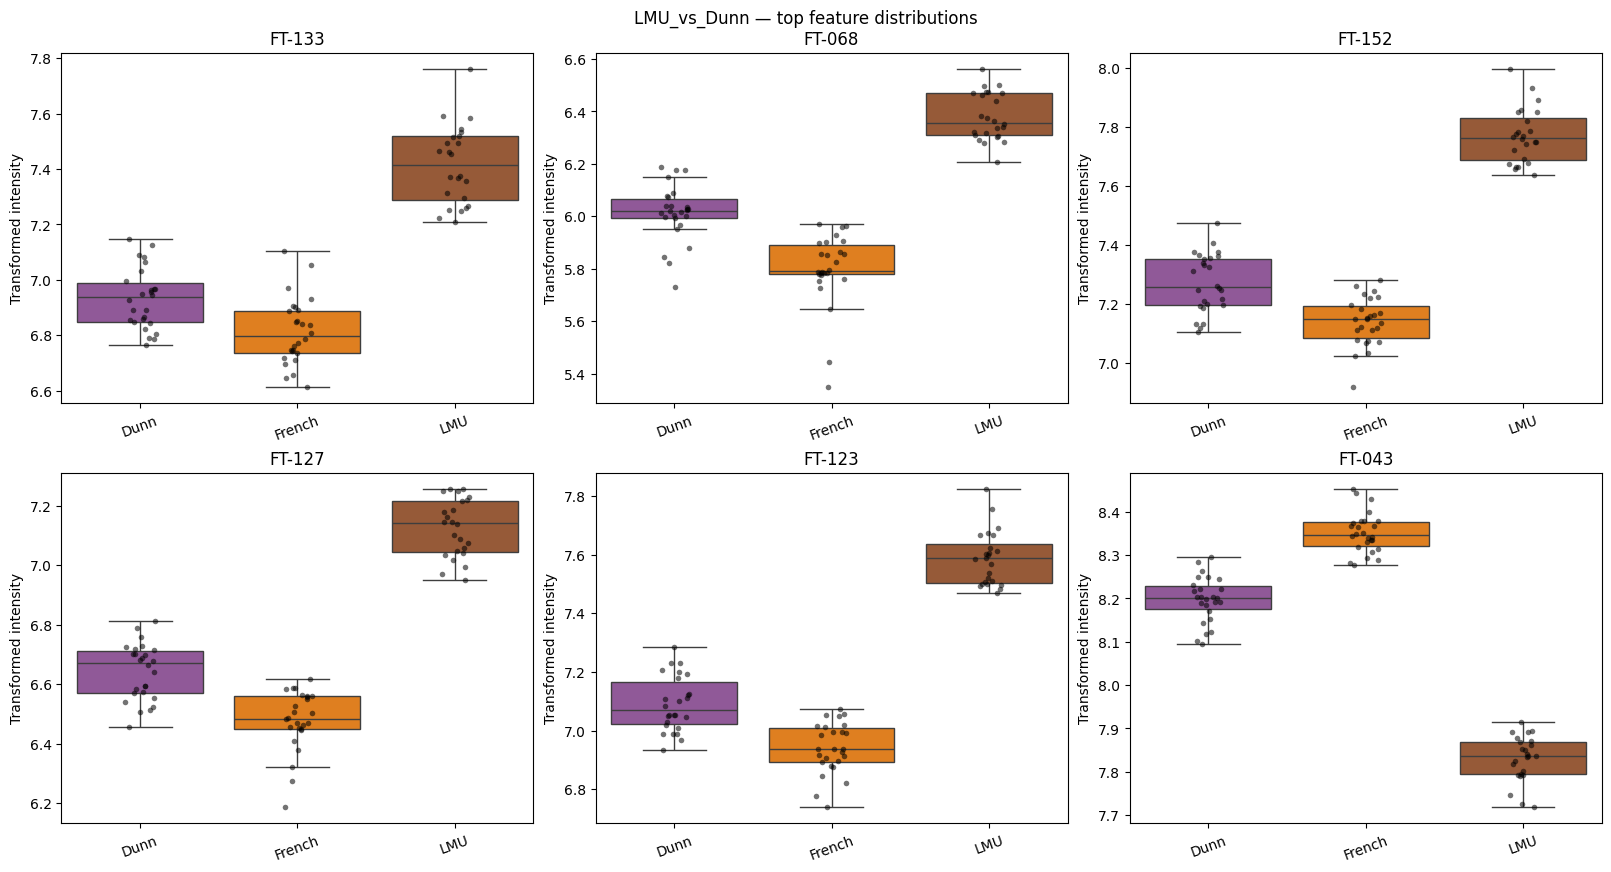

In [9]:
for task_name in ["French_vs_Dunn", "French_vs_LMU", "LMU_vs_Dunn"]:
    fig = plot_top_univariate_features(
        transformed_matrix=partc_inputs["partc_matrix_main"],
        sample_metadata=partc_inputs["partc_sample_metadata"],
        evidence_table=pairwise_tables_main[task_name],
        top_n=6,
    )
    fig.suptitle(f"{task_name} — top feature distributions", y=1.02)
    plt.show()

In [10]:
partc_step_dir = partc_inputs["processed_dir"].parent / "task1_partc_step4"
partc_step_dir.mkdir(parents=True, exist_ok=True)

freeze_summary.to_csv(partc_step_dir / "partc_freeze_summary.csv", index=False)
task_table.to_csv(partc_step_dir / "partc_task_table.csv", index=False)
pairwise_evidence_main.to_csv(partc_step_dir / "pairwise_univariate_evidence_main.csv", index=False)
pairwise_evidence_high.to_csv(partc_step_dir / "pairwise_univariate_evidence_high.csv", index=False)

for task_name, table in pairwise_tables_main.items():
    table.to_csv(partc_step_dir / f"{task_name}_main.csv", index=False)

for task_name, table in pairwise_tables_high.items():
    table.to_csv(partc_step_dir / f"{task_name}_high.csv", index=False)

print(f"Saved Part C step 1-4 outputs to: {partc_step_dir}")

Saved Part C step 1-4 outputs to: C:\Users\zakar\OneDrive\Bureau\ml-internship\data\processed\task1_partc_step4


### Interpretation of top feature distributions

The top-ranked features show visually coherent class-wise distributions that agree with the statistical evidence. Some features behave as cancer-enriched signals, while others distinguish benign disease from healthy controls or separate both disease groups from healthy samples. Features with very large fold-changes but sparse detection in one class are still informative, but they should be interpreted with more care than uniformly detected markers.

In [12]:
import importlib
import task1_discriminatory
importlib.reload(task1_discriminatory)

from task1_discriminatory import (
    load_partc_ready_inputs,
    build_partc_task_table,
    compute_partc_pca,
    plot_partc_pca,
    build_all_pairwise_univariate_evidence,
    plot_univariate_screen,
    plot_top_univariate_features,
    build_cluster_aware_evidence_table,
    run_pairwise_model_benchmarks,
    plot_model_benchmark_summary,
    plot_feature_stability,
    build_biomarker_hierarchy,
)

### Cluster-aware interpretation of the univariate results

The feature-level ranking shows very strong discriminatory signal, but many top-ranked features belong to the same redundancy clusters inherited from Part B. To avoid counting multiple correlated family members as independent biomarkers, we also summarize the evidence at the redundancy-cluster level. In this view, the representative feature acts as the cluster anchor, while the strongest feature in the cluster is tracked separately.

In [13]:
cluster_tables_main = {
    task_name: build_cluster_aware_evidence_table(table)
    for task_name, table in pairwise_tables_main.items()
}

cluster_summary_cols = [
    "cluster_rank_within_task",
    "redundancy_cluster_id",
    "redundancy_cluster_size",
    "feature",
    "redundancy_representative_flag",
    "best_feature_in_cluster",
    "representative_matches_best_feature",
    "effect_direction",
    "q_value",
    "best_q_value_in_cluster",
    "auc_abs",
    "best_auc_abs_in_cluster",
]

for task_name in ["French_vs_Dunn", "French_vs_LMU", "LMU_vs_Dunn"]:
    print(f"\n===== {task_name} — cluster-aware summary =====")
    available_cols = [c for c in cluster_summary_cols if c in cluster_tables_main[task_name].columns]
    display(cluster_tables_main[task_name][available_cols].head(15))


===== French_vs_Dunn — cluster-aware summary =====


,cluster_rank_within_task,redundancy_cluster_id,redundancy_cluster_size,feature,redundancy_representative_flag,best_feature_in_cluster,representative_matches_best_feature,effect_direction,q_value,best_q_value_in_cluster,auc_abs,best_auc_abs_in_cluster
0,1,RG-017,8,FT-046,True,FT-046,True,French > Dunn,6.788751e-09,6.788751e-09,1.000000,1.000000
1,2,RG-021,4,FT-030,True,FT-218,False,French < Dunn,6.788751e-09,6.788751e-09,1.000000,1.000000
2,3,RG-026,7,FT-021,True,FT-020,False,French < Dunn,6.788751e-09,6.788751e-09,1.000000,1.000000
3,4,RG-030,2,FT-179,True,FT-179,True,French > Dunn,5.150120e-08,5.150120e-08,0.965976,0.965976
4,5,RG-003,3,FT-174,True,FT-174,True,French > Dunn,5.859431e-08,5.859431e-08,0.961538,0.961538
5,6,RG-002,1,FT-015,True,FT-015,True,French < Dunn,1.450592e-07,1.450592e-07,0.948225,0.948225
6,7,RG-020,2,FT-178,True,FT-178,True,French > Dunn,1.744838e-07,1.744838e-07,0.945266,0.945266
7,8,RG-013,2,FT-110,True,FT-110,True,French < Dunn,2.729383e-07,2.729383e-07,0.937870,0.937870
8,9,RG-012,7,FT-040,True,FT-037,False,French < Dunn,1.172810e-06,3.282185e-08,0.912722,0.973373
9,10,RG-011,6,FT-168,True,FT-168,True,French > Dunn,6.387315e-06,6.387315e-06,0.884615,0.884615



===== French_vs_LMU — cluster-aware summary =====


,cluster_rank_within_task,redundancy_cluster_id,redundancy_cluster_size,feature,redundancy_representative_flag,best_feature_in_cluster,representative_matches_best_feature,effect_direction,q_value,best_q_value_in_cluster,auc_abs,best_auc_abs_in_cluster
0,1,RG-017,8,FT-046,True,FT-043,False,French > LMU,8.212233e-09,8.212233e-09,1.000000,1.000000
1,2,RG-024,9,FT-031,True,FT-031,True,French > LMU,8.212233e-09,8.212233e-09,1.000000,1.000000
2,3,RG-026,7,FT-021,True,FT-020,False,French < LMU,8.212233e-09,8.212233e-09,1.000000,1.000000
3,4,RG-021,4,FT-030,True,FT-218,False,French < LMU,1.675449e-08,1.161476e-08,0.985577,0.991987
4,5,RG-030,2,FT-179,True,FT-026,False,French > LMU,2.383620e-08,1.054754e-08,0.979167,0.993590
5,6,RG-020,2,FT-178,True,FT-178,True,French > LMU,5.040760e-08,5.040760e-08,0.967949,0.967949
6,7,RG-016,8,FT-102,True,FT-112,False,French > LMU,1.846140e-07,6.211096e-08,0.947115,0.964744
7,8,RG-001,2,FT-145,True,FT-145,True,French < LMU,6.323687e-07,6.323687e-07,0.927885,0.927885
8,9,RG-010,25,FT-076,True,FT-049,False,French > LMU,1.324367e-06,8.212233e-09,0.915064,1.000000
9,10,RG-028,1,FT-205,True,FT-205,True,French > LMU,2.322505e-06,2.322505e-06,0.905449,0.905449



===== LMU_vs_Dunn — cluster-aware summary =====


,cluster_rank_within_task,redundancy_cluster_id,redundancy_cluster_size,feature,redundancy_representative_flag,best_feature_in_cluster,representative_matches_best_feature,effect_direction,q_value,best_q_value_in_cluster,auc_abs,best_auc_abs_in_cluster
0,1,RG-017,8,FT-046,True,FT-043,False,LMU < Dunn,1.197617e-08,1.197617e-08,1.000000,1.000000
1,2,RG-021,4,FT-030,True,FT-218,False,LMU < Dunn,1.197617e-08,1.197617e-08,1.000000,1.000000
2,3,RG-024,9,FT-031,True,FT-032,False,LMU < Dunn,1.364975e-08,1.197617e-08,0.993590,1.000000
3,4,RG-010,25,FT-076,True,FT-193,False,LMU < Dunn,5.906301e-07,1.197617e-08,0.934295,1.000000
4,5,RG-001,2,FT-145,True,FT-145,True,LMU > Dunn,5.513853e-06,5.513853e-06,0.897436,0.897436
5,6,RG-005,1,FT-028,True,FT-028,True,LMU < Dunn,1.123589e-05,1.123589e-05,0.884615,0.884615
6,7,RG-006,1,FT-156,True,FT-156,True,LMU < Dunn,2.171789e-05,2.171789e-05,0.871795,0.871795
7,8,RG-016,8,FT-102,True,FT-112,False,LMU < Dunn,3.508034e-05,1.802970e-07,0.862179,0.953526
8,9,RG-011,6,FT-168,True,FT-169,False,LMU > Dunn,5.218387e-05,1.332477e-05,0.854167,0.881410
9,10,RG-018,12,FT-161,True,FT-158,False,LMU > Dunn,1.052897e-04,8.393241e-05,0.839744,0.844551


### Multivariate predictive benchmark

The univariate results are strong, but they do not tell us whether the signal remains stable in a predictive setting. We therefore benchmark simple interpretable linear models with repeated stratified cross-validation. Feature selection is performed inside each training fold to avoid information leakage. We compare three feature spaces: the full retained set, the high-confidence subset, and the representative-only redundancy-reduced set.

In [14]:
fold_metrics_df, benchmark_summary_df, feature_stability_df = run_pairwise_model_benchmarks(
    partc_inputs=partc_inputs,
    task_table=task_table,
    feature_spaces=("main", "high", "representative"),
    model_names=("logreg_l1", "linear_svm"),
    k_best=20,
    n_splits=5,
    n_repeats=10,
    random_state=42,
)

display(benchmark_summary_df)
display(feature_stability_df.head(20))

,task_name,feature_space,model_name,mean_auroc,std_auroc,mean_balanced_accuracy,std_balanced_accuracy,mean_f1,mean_precision,mean_recall,n_folds
0,French_vs_Dunn,high,logreg_l1,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
1,French_vs_Dunn,main,linear_svm,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
2,French_vs_Dunn,main,logreg_l1,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
3,French_vs_Dunn,representative,linear_svm,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
4,French_vs_Dunn,representative,logreg_l1,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
5,French_vs_Dunn,high,linear_svm,1.0,0.0,0.996,0.019795,0.996364,0.993333,1.000,50
6,French_vs_LMU,high,linear_svm,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
7,French_vs_LMU,high,logreg_l1,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
8,French_vs_LMU,main,linear_svm,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
9,French_vs_LMU,main,logreg_l1,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50


,task_name,feature_space,model_name,feature,n_selected,mean_coef,mean_abs_coef,positive_coef_fraction,n_folds,selection_frequency,sign_consistency
0,French_vs_Dunn,high,linear_svm,FT-040,50,-0.171144,0.171144,0.000000,50,1.00,1.000000
1,French_vs_Dunn,high,linear_svm,FT-046,50,0.157600,0.157600,1.000000,50,1.00,1.000000
2,French_vs_Dunn,high,linear_svm,FT-050,50,0.137969,0.137969,1.000000,50,1.00,1.000000
3,French_vs_Dunn,high,linear_svm,FT-174,50,0.132288,0.132288,1.000000,50,1.00,1.000000
4,French_vs_Dunn,high,linear_svm,FT-095,50,-0.125181,0.125181,0.000000,50,1.00,1.000000
5,French_vs_Dunn,high,linear_svm,FT-110,50,-0.113341,0.113341,0.000000,50,1.00,1.000000
6,French_vs_Dunn,high,linear_svm,FT-233,50,-0.102733,0.102733,0.000000,50,1.00,1.000000
7,French_vs_Dunn,high,linear_svm,FT-178,50,0.101656,0.101656,1.000000,50,1.00,1.000000
8,French_vs_Dunn,high,linear_svm,FT-043,50,0.094895,0.094895,1.000000,50,1.00,1.000000
9,French_vs_Dunn,high,linear_svm,FT-056,50,-0.072690,0.072690,0.000000,50,1.00,1.000000


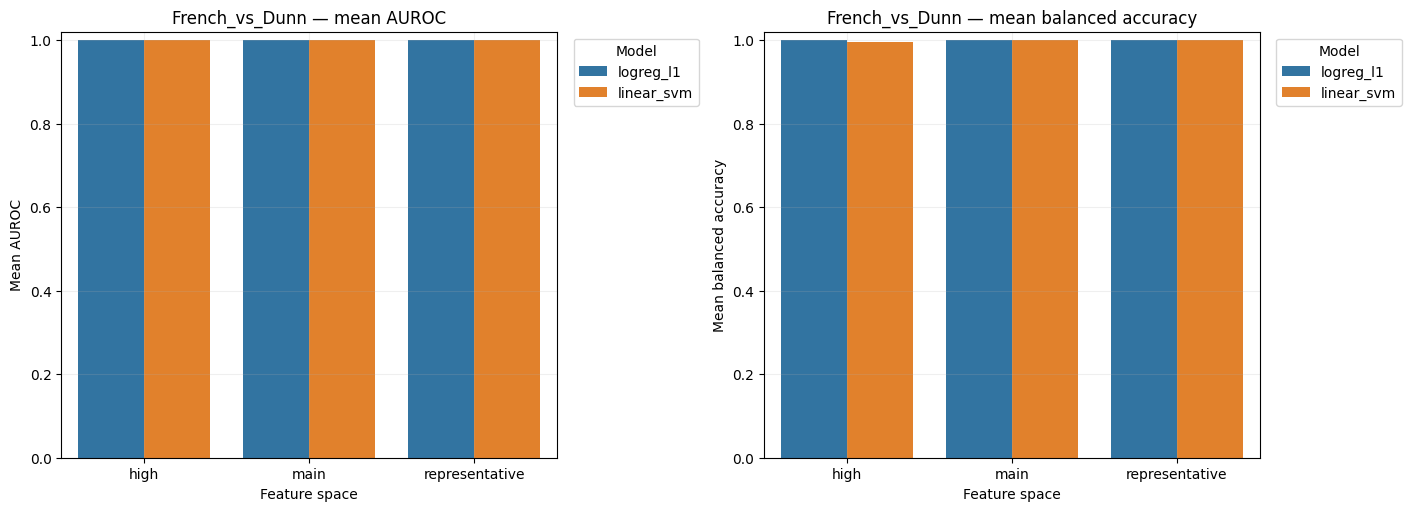

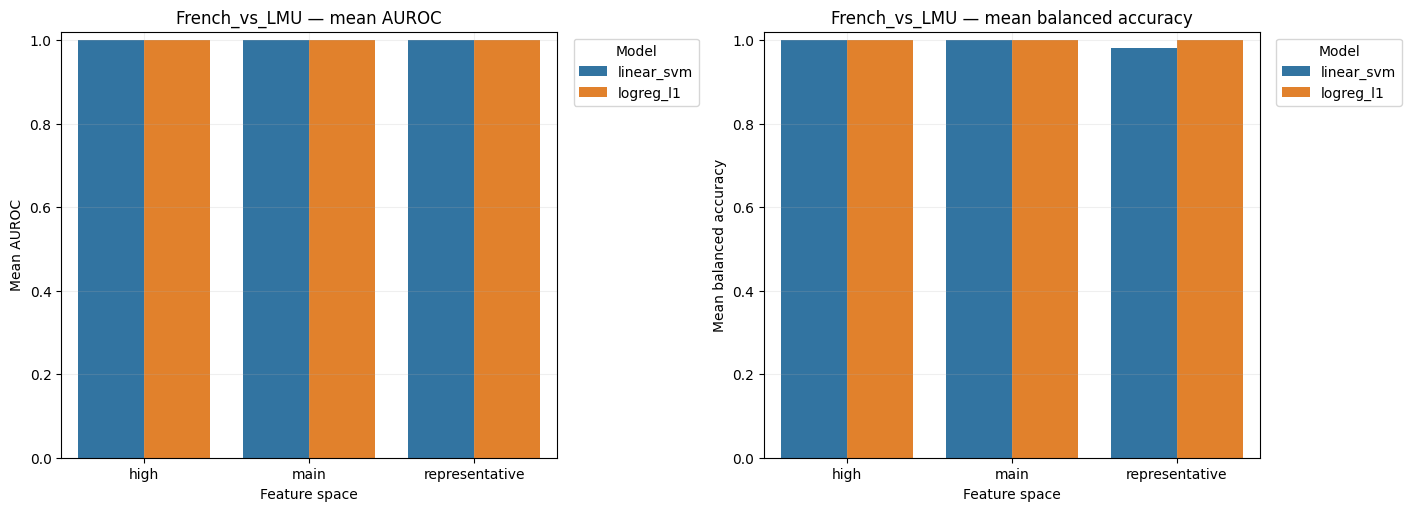

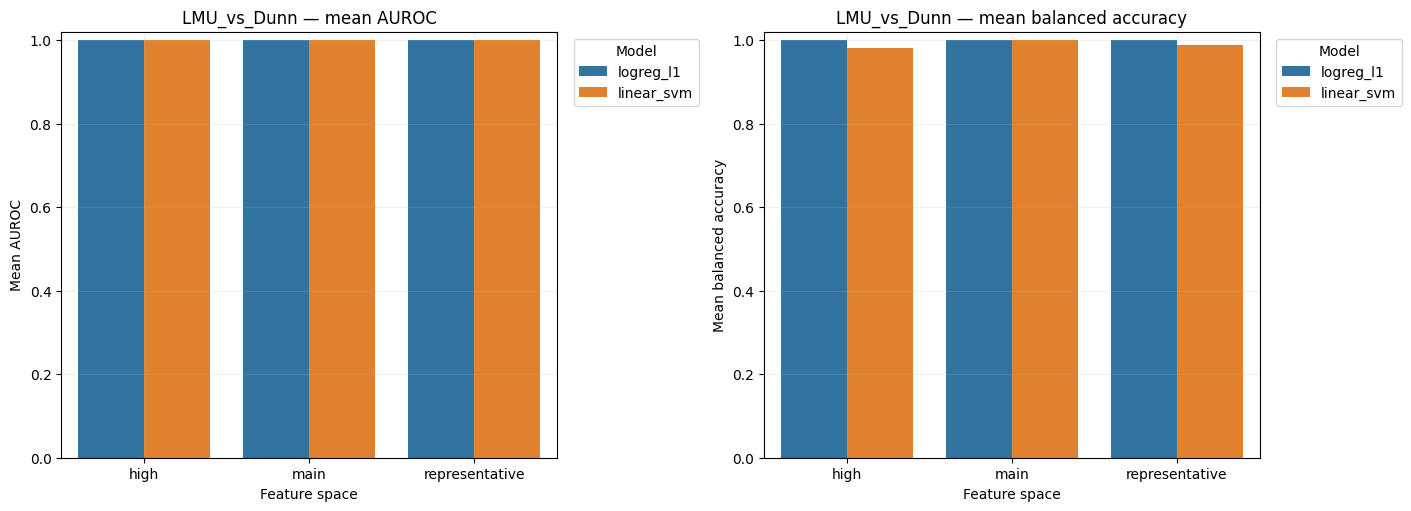

In [15]:
for task_name in ["French_vs_Dunn", "French_vs_LMU", "LMU_vs_Dunn"]:
    fig = plot_model_benchmark_summary(benchmark_summary_df, task_name=task_name)
    plt.show()

### Interpretation of predictive benchmarking

Linear models achieve near-perfect discrimination across the main, high-confidence, representative, and warning-filtered feature spaces. This indicates that the retained signal is highly structured and not dependent on a single feature subset. Because these results are extremely strong, they should be interpreted as evidence of very high separability in the curated batch-1 discovery dataset rather than as proof of external generalization.

### Feature stability across cross-validation folds

A useful biomarker should not only look strong in one ranking table; it should also appear repeatedly across cross-validation folds. We therefore track how often each feature is selected and how consistent its coefficient sign remains. This helps separate stable discriminatory features from signals that are strong but redundant or unstable.

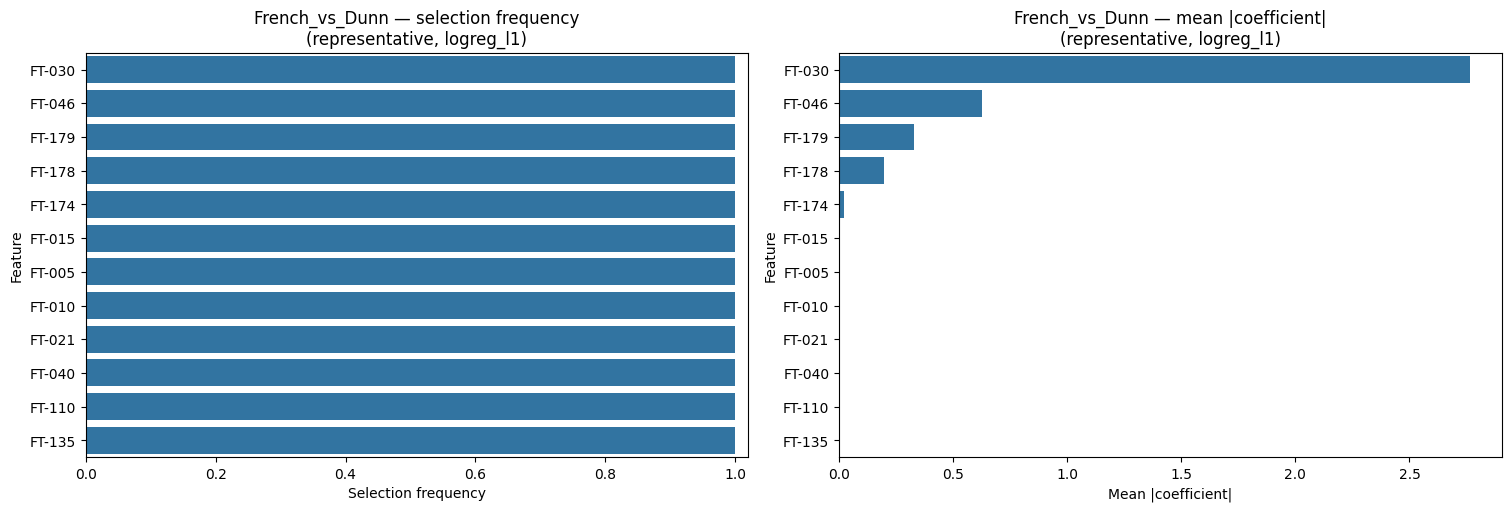

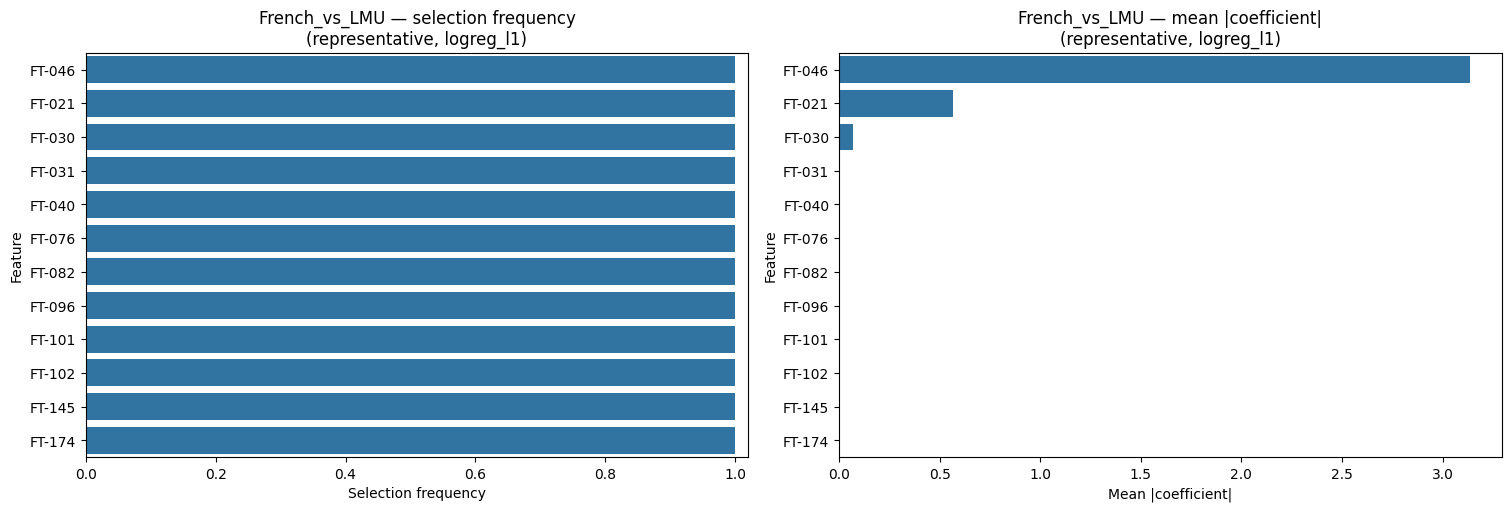

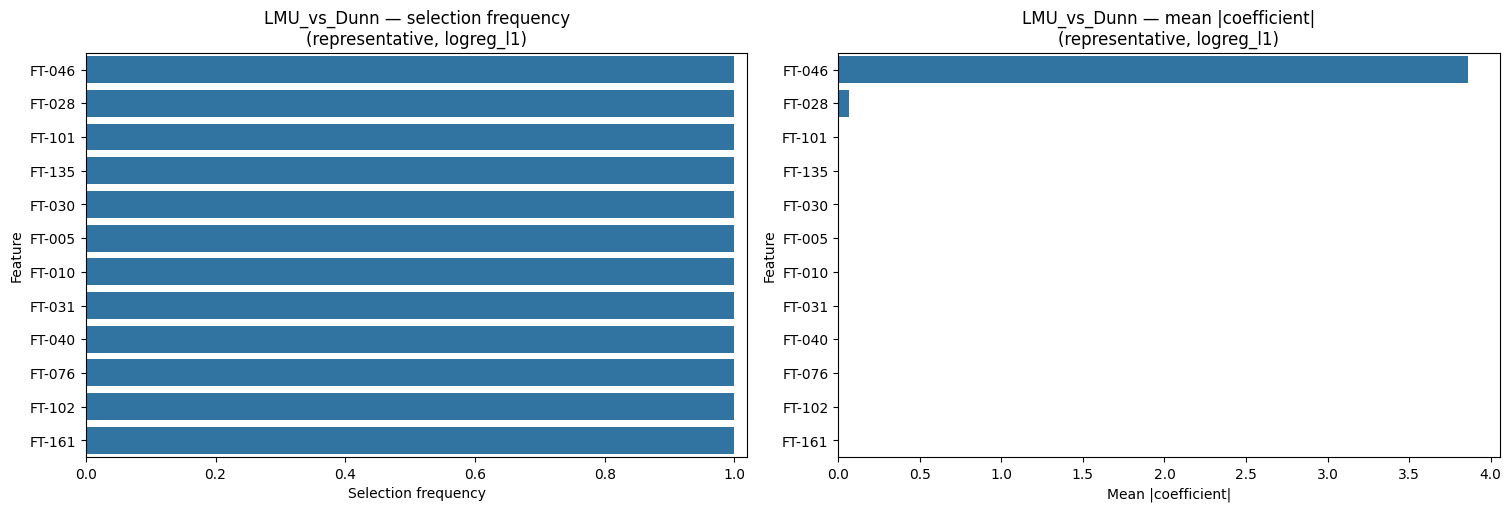

In [16]:
for task_name in ["French_vs_Dunn", "French_vs_LMU", "LMU_vs_Dunn"]:
    fig = plot_feature_stability(
        feature_stability_df,
        task_name=task_name,
        feature_space="representative",
        model_name="logreg_l1",
        top_n=12,
    )
    plt.show()

### Interpretation of feature stability

Several representative features are selected consistently across repeated cross-validation folds, which strengthens their credibility beyond a single model fit. This stability is particularly important in a redundancy-heavy setting, because it helps distinguish robust cluster-level signals from weaker supportive family members. The final prioritization therefore combines statistical evidence, cluster-aware interpretation, and model-selection stability.

### Final hierarchy of candidate biomarkers

The final shortlist combines three evidence layers: univariate separation, redundancy-aware interpretation, and multivariate stability. Tier 1 features are the most defensible candidates because they combine strong statistical evidence, good predictive utility, and stable selection behavior, while avoiding obvious technical warnings. Lower tiers retain useful supporting signals but should be interpreted more cautiously.

In [17]:
biomarker_hierarchy = build_biomarker_hierarchy(
    pairwise_tables_main=pairwise_tables_main,
    feature_stability_df=feature_stability_df,
    feature_manifest_main=partc_inputs["feature_manifest_main"],
    model_name="logreg_l1",
)

hierarchy_cols = [
    "feature",
    "target_tier",
    "redundancy_cluster_id",
    "redundancy_cluster_size",
    "redundancy_representative_flag",
    "retained_high_confidence",
    "best_q_value",
    "best_auc_abs",
    "n_tasks_significant",
    "n_tasks_auc_ge_090",
    "max_selection_frequency",
    "max_sign_consistency",
    "blank_dominant_veto",
    "potential_carryover_flag",
]

available_hierarchy_cols = [c for c in hierarchy_cols if c in biomarker_hierarchy.columns]
display(biomarker_hierarchy[available_hierarchy_cols].head(30))

display(
    biomarker_hierarchy["target_tier"]
    .value_counts(dropna=False)
    .rename_axis("target_tier")
    .reset_index(name="n_features")
)

,feature,target_tier,redundancy_cluster_id,redundancy_cluster_size,redundancy_representative_flag,retained_high_confidence,best_q_value,best_auc_abs,n_tasks_significant,n_tasks_auc_ge_090,max_selection_frequency,max_sign_consistency,blank_dominant_veto,potential_carryover_flag
0,FT-046,Tier 1,RG-017,8,True,True,6.788751e-09,1.000000,3,3,1.00,1.00,False,False
1,FT-178,Tier 1,RG-020,2,True,True,5.040760e-08,0.967949,2,2,1.00,1.00,False,False
2,FT-174,Tier 1,RG-003,3,True,True,5.859431e-08,0.961538,2,1,1.00,1.00,False,False
3,FT-015,Tier 1,RG-002,1,True,True,1.450592e-07,0.948225,3,1,1.00,1.00,False,False
4,FT-102,Tier 1,RG-016,8,True,True,1.846140e-07,0.947115,2,1,1.00,1.00,False,False
5,FT-110,Tier 1,RG-013,2,True,True,2.729383e-07,0.937870,2,1,1.00,1.00,False,False
6,FT-076,Tier 1,RG-010,25,True,True,5.906301e-07,0.934295,2,2,1.00,1.00,False,False
7,FT-145,Tier 1,RG-001,2,True,True,6.323687e-07,0.927885,3,1,1.00,1.00,False,False
8,FT-040,Tier 1,RG-012,7,True,True,1.172810e-06,0.912722,3,1,1.00,1.00,False,False
9,FT-021,Tier 2,RG-026,7,True,False,6.788751e-09,1.000000,3,2,1.00,1.00,False,False


,target_tier,n_features
0,Tier 3,108
1,Tier 3_supportive_family_member,72
2,Tier 1,9
3,Tier 2,8


In [18]:
from pathlib import Path

project_root = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
partc_dir = project_root / "data" / "processed" / "task1_partc"
partc_dir.mkdir(parents=True, exist_ok=True)

benchmark_summary_df.to_csv(partc_dir / "pairwise_model_benchmark_summary.csv", index=False)
fold_metrics_df.to_csv(partc_dir / "pairwise_model_benchmark_folds.csv", index=False)
feature_stability_df.to_csv(partc_dir / "pairwise_feature_stability.csv", index=False)
biomarker_hierarchy.to_csv(partc_dir / "biomarker_hierarchy.csv", index=False)

for task_name, table in pairwise_tables_main.items():
    table.to_csv(partc_dir / f"{task_name.lower()}_univariate_main.csv", index=False)

for task_name, table in cluster_tables_main.items():
    table.to_csv(partc_dir / f"{task_name.lower()}_cluster_aware.csv", index=False)

print(f"Saved Part C outputs to: {partc_dir}")

Saved Part C outputs to: C:\Users\zakar\OneDrive\Bureau\ml-internship\data\processed\task1_partc


In [19]:
import importlib
import task1_discriminatory
importlib.reload(task1_discriminatory)

from task1_discriminatory import (
    build_feature_clinical_profile_table,
    plot_pairwise_decision_boundary,
    build_warning_filtered_feature_space,
    run_pairwise_model_benchmarks_from_space_dict,
    build_final_biomarker_decision_table,
)

### 9. Clinical profile of the top discriminatory signals

Strong discrimination is not enough on its own: we also want to understand *what kind* of separation each feature is capturing. In this step, each retained feature is assigned a compact clinical profile based on its pairwise evidence and its class-level median pattern. This helps distinguish cancer-specific signals from benign-associated, healthy-associated, or more general disease-related signals.

In [20]:
feature_profile_table = build_feature_clinical_profile_table(
    pairwise_tables_main=pairwise_tables_main,
    transformed_matrix=partc_inputs["partc_matrix_main"],
    sample_metadata=partc_inputs["partc_sample_metadata"],
    min_auc=0.85,
    max_q=0.05,
    min_abs_log2_fc=0.10,
)

profile_summary = (
    biomarker_hierarchy[["feature", "target_tier", "redundancy_cluster_id", "redundancy_representative_flag"]]
    .merge(
        feature_profile_table[["feature", "clinical_profile", "profile_note", "French", "LMU", "Dunn", "n_strong_tasks"]],
        on="feature",
        how="left",
    )
)

display(
    profile_summary.loc[
        profile_summary["target_tier"].isin(["Tier 1", "Tier 2"]),
        ["feature", "target_tier", "redundancy_cluster_id", "clinical_profile", "n_strong_tasks", "French", "LMU", "Dunn", "profile_note"],
    ].sort_values(["target_tier", "feature"]).reset_index(drop=True)
)

display(
    profile_summary["clinical_profile"]
    .value_counts(dropna=False)
    .rename_axis("clinical_profile")
    .reset_index(name="n_features")
)

,feature,target_tier,redundancy_cluster_id,clinical_profile,n_strong_tasks,French,LMU,Dunn,profile_note
0,FT-015,Tier 1,RG-002,cancer-specific low,2,7.311098,7.562874,7.617092,French is clearly depleted relative to both co...
1,FT-040,Tier 1,RG-012,healthy-associated,1,6.595751,6.711106,6.789560,Dunn is highest overall.
2,FT-046,Tier 1,RG-017,cancer-specific high,3,8.931133,8.438271,8.782871,"French is highest, while LMU stays below healthy."
3,FT-076,Tier 1,RG-010,benign-depleted,2,10.007996,9.950002,10.015184,LMU is specifically low for this feature.
4,FT-102,Tier 1,RG-016,benign-depleted,2,6.406923,6.240582,6.380332,LMU is specifically low for this feature.
5,FT-110,Tier 1,RG-013,cancer-specific low,2,7.941098,8.052948,8.055319,French is clearly depleted relative to both co...
6,FT-145,Tier 1,RG-001,benign-associated,2,6.585209,7.182893,6.682618,LMU is the dominant class for this feature.
7,FT-174,Tier 1,RG-003,healthy-depleted,1,4.562984,1.948486,1.820152,Dunn is lowest overall.
8,FT-178,Tier 1,RG-020,cancer-specific high,2,7.407156,7.224649,7.237011,French is clearly highest relative to both com...
9,FT-021,Tier 2,RG-026,cancer-specific low,2,9.470103,9.698976,9.732049,French is clearly depleted relative to both co...


,clinical_profile,n_features
0,non-specific but discriminative,65
1,benign-depleted,31
2,healthy-depleted,30
3,cancer-specific low,27
4,healthy-associated,21
5,cancer-specific high,16
6,benign-associated,7


### 10. Compact decision-boundary view

The README explicitly asks for decision boundaries to support biomarker justification. Rather than overloading the notebook with many classifier plots, we show one compact 2D boundary per pairwise task using the top representative features from the cluster-aware ranking. This makes the separation visually concrete while staying aligned with the redundancy-aware interpretation.

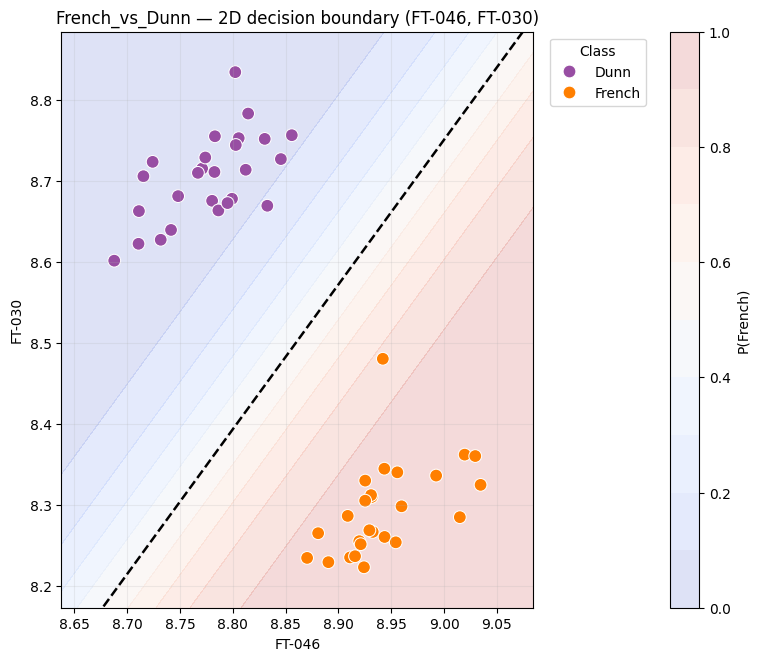

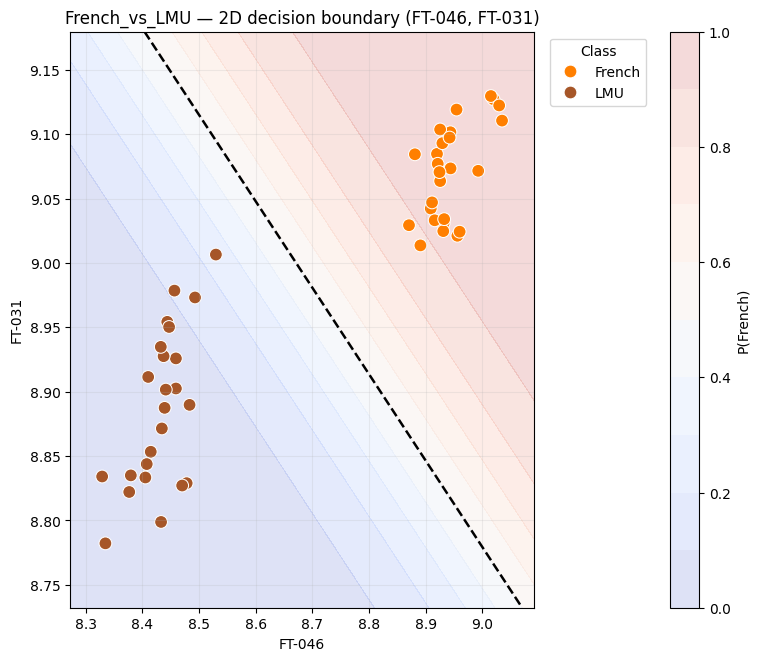

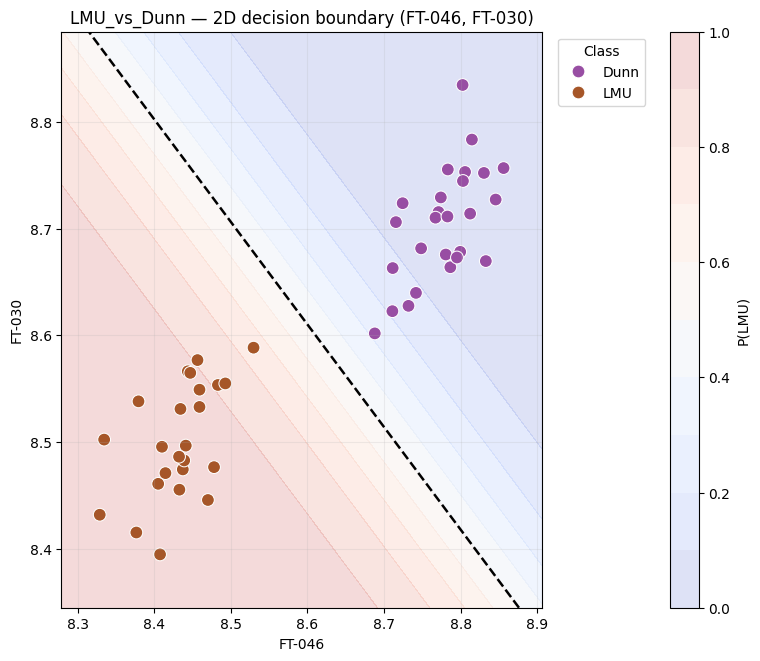

In [21]:
task_meta = task_table.set_index("task_name")

for task_name in ["French_vs_Dunn", "French_vs_LMU", "LMU_vs_Dunn"]:
    fig = plot_pairwise_decision_boundary(
        transformed_matrix=partc_inputs["partc_matrix_main"],
        sample_metadata=partc_inputs["partc_sample_metadata"],
        cluster_aware_table=cluster_tables_main[task_name],
        positive_class=task_meta.loc[task_name, "positive_class"],
        negative_class=task_meta.loc[task_name, "negative_class"],
        title_prefix=task_name,
    )
    plt.show()

### Interpretation of decision boundaries

Simple two-feature combinations already produce clean linear decision boundaries for the main pairwise tasks. This supports the view that discrimination is not only statistically significant but also practically simple in the retained feature space. These plots are illustrative rather than definitive, but they make the separation between classes concrete and interpretable.

### 11. Compact robustness check

The earlier model benchmark already showed that the class signal remains strong across the full retained set, the high-confidence subset, and the representative-only space. Here we add one extra sensitivity check by removing carryover- or blank-warning features from the main retained set. The goal is not to chase a higher score, but to verify that the conclusions do not depend on a small number of technically flagged features.

In [23]:
main_no_warning_matrix, raw_no_warning_matrix, main_no_warning_manifest = build_warning_filtered_feature_space(
    partc_inputs=partc_inputs,
    base_feature_space="main",
    exclude_carryover=True,
    exclude_blank_dominant=True,
)

matrix_space_dict = {
    "main": partc_inputs["partc_matrix_main"],
    "high": partc_inputs["partc_matrix_high"],
    "representative": partc_inputs["partc_matrix_representative"],
    "main_no_warnings": main_no_warning_matrix,
}

robust_fold_metrics_df, robust_benchmark_summary_df = run_pairwise_model_benchmarks_from_space_dict(
    matrix_space_dict=matrix_space_dict,
    sample_metadata=partc_inputs["partc_sample_metadata"],
    task_table=task_table,
    model_names=("logreg_l1", "linear_svm"),
    k_best=20,
    n_splits=5,
    n_repeats=10,
    random_state=42,
)

n_main_features = partc_inputs["partc_matrix_main"].shape[1] - 1
n_main_no_warning_features = main_no_warning_matrix.shape[1] - 1

print(f"Main retained features: {n_main_features}")
print(f"Main retained features after removing warning-flagged features: {n_main_no_warning_features}")

display(robust_benchmark_summary_df)

Main retained features: 197
Main retained features after removing warning-flagged features: 194


,task_name,feature_space,model_name,mean_auroc,std_auroc,mean_balanced_accuracy,std_balanced_accuracy,mean_f1,mean_precision,mean_recall,n_folds
0,French_vs_Dunn,high,logreg_l1,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
1,French_vs_Dunn,main,linear_svm,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
2,French_vs_Dunn,main,logreg_l1,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
3,French_vs_Dunn,main_no_warnings,linear_svm,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
4,French_vs_Dunn,main_no_warnings,logreg_l1,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
5,French_vs_Dunn,representative,linear_svm,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
6,French_vs_Dunn,representative,logreg_l1,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
7,French_vs_Dunn,high,linear_svm,1.0,0.0,0.996,0.019795,0.996364,0.993333,1.000,50
8,French_vs_LMU,high,linear_svm,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50
9,French_vs_LMU,high,logreg_l1,1.0,0.0,1.000,0.000000,1.000000,1.000000,1.000,50


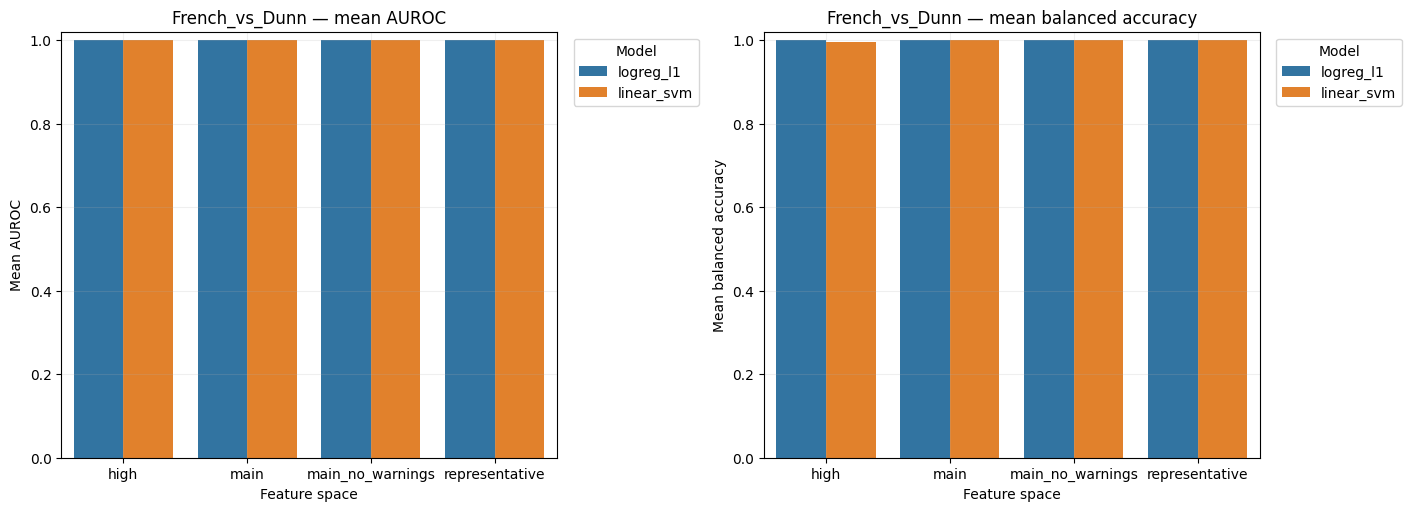

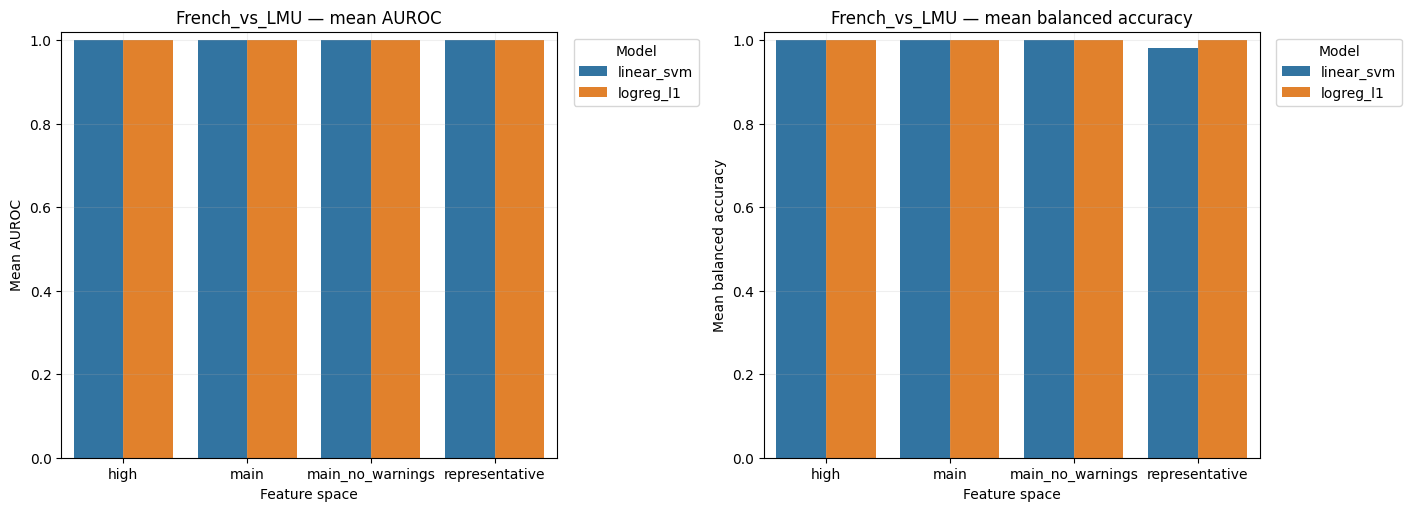

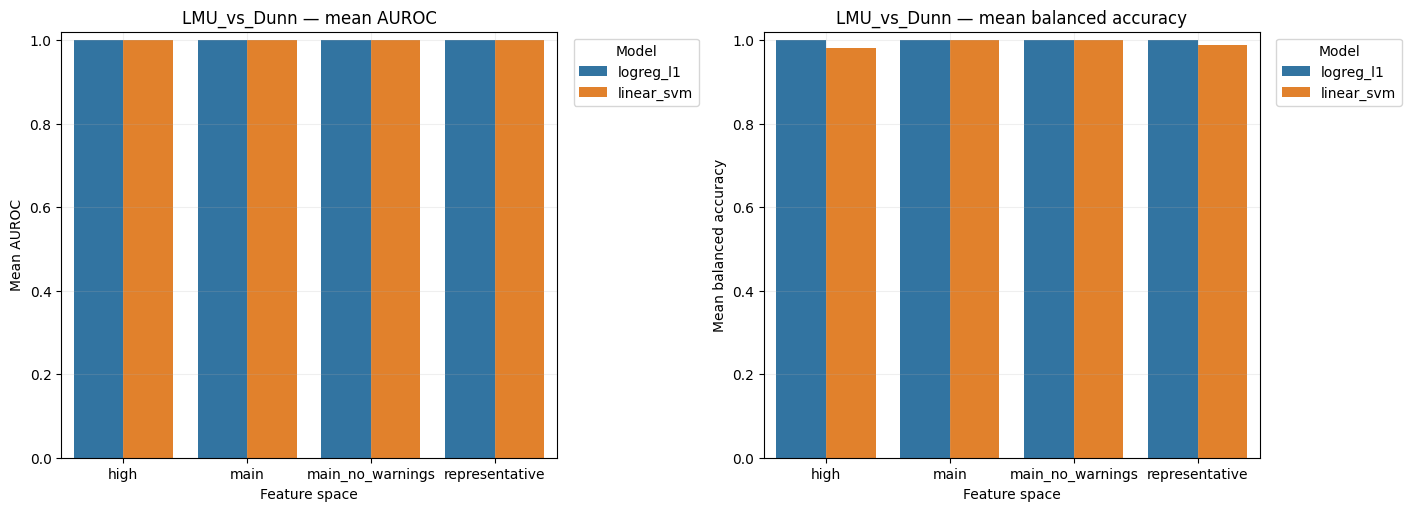

In [24]:
for task_name in ["French_vs_Dunn", "French_vs_LMU", "LMU_vs_Dunn"]:
    fig = plot_model_benchmark_summary(robust_benchmark_summary_df, task_name=task_name)
    plt.show()

### 12. Final biomarker decision table

The final deliverable of Part C is a compact decision table for the top-priority candidates. It combines redundancy-aware priority tier, clinical profile, pairwise effect sizes, adjusted significance, discrimination strength, model stability, and technical warnings. This table is the cleanest handoff from exploratory discrimination to a final shortlist of candidate biomarkers.

In [25]:
final_biomarker_decision_table = build_final_biomarker_decision_table(
    biomarker_hierarchy=biomarker_hierarchy,
    feature_profile_table=feature_profile_table,
    pairwise_tables_main=pairwise_tables_main,
    feature_stability_df=feature_stability_df,
    keep_tiers=("Tier 1", "Tier 2"),
    model_name="logreg_l1",
    representative_only=True,
)

decision_cols = [
    "priority_rank",
    "feature",
    "target_tier",
    "redundancy_cluster_id",
    "redundancy_cluster_size",
    "retained_high_confidence",
    "clinical_profile",
    "biological_interpretation_note",
    "best_q_value",
    "best_auc_abs",
    "model_max_selection_frequency",
    "qc_cv_pct",
    "d_ratio_log",
    "blank_dominant_veto",
    "potential_carryover_flag",
    "effect_direction__French_vs_Dunn",
    "raw_log2_fc__French_vs_Dunn",
    "q_value__French_vs_Dunn",
    "auc_abs__French_vs_Dunn",
    "effect_direction__French_vs_LMU",
    "raw_log2_fc__French_vs_LMU",
    "q_value__French_vs_LMU",
    "auc_abs__French_vs_LMU",
    "effect_direction__LMU_vs_Dunn",
    "raw_log2_fc__LMU_vs_Dunn",
    "q_value__LMU_vs_Dunn",
    "auc_abs__LMU_vs_Dunn",
]

available_decision_cols = [c for c in decision_cols if c in final_biomarker_decision_table.columns]
display(final_biomarker_decision_table[available_decision_cols])

,priority_rank,feature,target_tier,redundancy_cluster_id,redundancy_cluster_size,retained_high_confidence,clinical_profile,biological_interpretation_note,best_q_value,best_auc_abs,...,q_value__French_vs_Dunn,auc_abs__French_vs_Dunn,effect_direction__French_vs_LMU,raw_log2_fc__French_vs_LMU,q_value__French_vs_LMU,auc_abs__French_vs_LMU,effect_direction__LMU_vs_Dunn,raw_log2_fc__LMU_vs_Dunn,q_value__LMU_vs_Dunn,auc_abs__LMU_vs_Dunn
0,1,FT-046,Tier 1,RG-017,8,True,cancer-specific high,"French is highest, while LMU stays below healthy.",6.788751e-09,1.000000,...,6.788751e-09,1.000000,French > LMU,0.778632,8.212233e-09,1.000000,LMU < Dunn,-0.605579,1.197617e-08,1.000000
1,2,FT-178,Tier 1,RG-020,2,True,cancer-specific high,French is clearly highest relative to both com...,5.040760e-08,0.967949,...,1.744838e-07,0.945266,French > LMU,0.282269,5.040760e-08,0.967949,LMU < Dunn,-0.115731,6.387295e-01,0.544872
2,3,FT-174,Tier 1,RG-003,3,True,healthy-depleted,Dunn is lowest overall.,5.859431e-08,0.961538,...,5.859431e-08,0.961538,French > LMU,3.975623,1.039516e-04,0.833333,LMU > Dunn,-0.037696,8.069150e-01,0.522436
3,4,FT-015,Tier 1,RG-002,1,True,cancer-specific low,French is clearly depleted relative to both co...,1.450592e-07,0.948225,...,1.450592e-07,0.948225,French < LMU,-0.323739,7.059622e-06,0.886218,LMU < Dunn,-0.193825,3.603447e-03,0.754808
4,5,FT-102,Tier 1,RG-016,8,True,benign-depleted,LMU is specifically low for this feature.,1.846140e-07,0.947115,...,1.863630e-01,0.615385,French > LMU,0.249492,1.846140e-07,0.947115,LMU < Dunn,-0.297416,3.508034e-05,0.862179
5,6,FT-110,Tier 1,RG-013,2,True,cancer-specific low,French is clearly depleted relative to both co...,2.729383e-07,0.937870,...,2.729383e-07,0.937870,French < LMU,-0.135543,3.653758e-06,0.897436,LMU < Dunn,-0.146031,8.978805e-01,0.512821
6,7,FT-076,Tier 1,RG-010,25,True,benign-depleted,LMU is specifically low for this feature.,5.906301e-07,0.934295,...,4.559273e-01,0.568047,French > LMU,0.190354,1.324367e-06,0.915064,LMU < Dunn,-0.261201,5.906301e-07,0.934295
7,8,FT-145,Tier 1,RG-001,2,True,benign-associated,LMU is the dominant class for this feature.,6.323687e-07,0.927885,...,1.248578e-04,0.826923,French < LMU,-0.883498,6.323687e-07,0.927885,LMU > Dunn,0.579907,5.513853e-06,0.897436
8,9,FT-040,Tier 1,RG-012,7,True,healthy-associated,Dunn is highest overall.,1.172810e-06,0.912722,...,1.172810e-06,0.912722,French < LMU,-0.188865,3.896019e-03,0.750000,LMU < Dunn,-0.215014,7.073787e-04,0.794872
9,10,FT-021,Tier 2,RG-026,7,False,cancer-specific low,French is clearly depleted relative to both co...,6.788751e-09,1.000000,...,6.788751e-09,1.000000,French < LMU,-0.302151,8.212233e-09,1.000000,LMU < Dunn,-0.164612,2.069108e-02,0.701923


In [26]:
from pathlib import Path

project_root = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
partc_dir = project_root / "data" / "processed" / "task1_partc"
partc_dir.mkdir(parents=True, exist_ok=True)

feature_profile_table.to_csv(partc_dir / "feature_clinical_profile_table.csv", index=False)
robust_benchmark_summary_df.to_csv(partc_dir / "pairwise_model_benchmark_robustness.csv", index=False)
robust_fold_metrics_df.to_csv(partc_dir / "pairwise_model_benchmark_robustness_folds.csv", index=False)
final_biomarker_decision_table.to_csv(partc_dir / "final_biomarker_decision_table.csv", index=False)

print(f"Saved additional Part C outputs to: {partc_dir}")

Saved additional Part C outputs to: C:\Users\zakar\OneDrive\Bureau\ml-internship\data\processed\task1_partc


## Part C conclusion

Using the curated Part B dataset, Part C identified a highly discriminative feature space for the three biological groups. Pairwise statistical analysis showed strong and consistent evidence for class separation, especially for lung cancer versus healthy controls and lung cancer versus benign disease. Redundancy-aware analysis further showed that many top-ranked features belong to a smaller number of dominant signal families, so the final interpretation should focus on representative biomarkers rather than raw feature counts.

The predictive layer confirmed that the curated feature sets remain highly separable across multiple linear models and across stricter feature-space definitions. Combining univariate evidence, redundancy-aware ranking, feature stability, and simple decision-boundary visualization leads to a final hierarchy of candidate biomarkers with stronger support for Tier 1 representatives and secondary support for related family members.

Overall, the retained batch-1 data appear well suited for biomarker discovery, and the final prioritized candidates provide a solid handoff for downstream interpretation and eventual glycan-level characterization.